   Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0   1          60         65.0     8450            7            5       2003   
1   2          20         80.0     9600            6            8       1976   
2   3          60         68.0    11250            7            5       2001   
3   4          70         60.0     9550            7            5       1915   
4   5          60         84.0    14260            8            5       2000   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  SaleType_ConLw  SaleType_New  \
0          2003       196.0         706  ...           False         False   
1          1976         0.0         978  ...           False         False   
2          2002       162.0         486  ...           False         False   
3          1970         0.0         216  ...           False         False   
4          2000       350.0         655  ...           False         False   

   SaleType_Oth  SaleType_WD  SaleCondition_Abnorm

/Users/jeongminjae/Desktop/deep-learning-course/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 721 (2.82 KB)

 Trainable params: 721 (2.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2000
 1/44 ━━━━━━━━━━━━━━━━━━━━ 10s 242ms/step - loss: 41571000320.0000
Epoch 1: val_loss improved from None to 39083839488.00000, saving model to ./model/house2.keras

Epoch 1: finished saving model to ./model/house2.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 39581282304.0000 - val_loss: 39083839488.0000
Epoch 2/2000
 1/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 34989268992.0000
Epoch 2: val_loss improved from 39083839488.00000 to 38774714368.00000, saving model to ./model/house2.keras

Epoch 2: finished saving model to ./model/house2.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step - loss: 39391506432.0000 - val_loss: 38774714368.0000
Epoch 3/2000
 1/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 39777771520.0000
Epoch 3: val_loss improved from 38774714368.00000 to 37893533696.00000, saving model to ./model/house2.keras

Epoch 3: finished saving model to ./model/house2.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step - loss: 38842482688.0000 - val_loss: 37893533696.0000
E

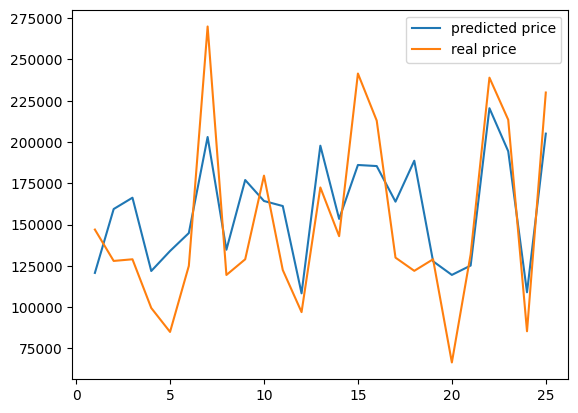

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

df = pd.read_csv("../datasets/house_data.csv")

# 카테고리형 변수를 0과 1로 이루어진 변수로 변경
df = pd.get_dummies(df)

# 결측치를 전체 칼럼의 평균으로 대체
df = df.fillna(df.mean())

print(df.head())

# 집 값을 제외한 나머지 열을 저장
cols_train = ['OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF']
X_train_pre = df[cols_train]

y = df['SalePrice'].values
X_train_pre = X_train_pre.astype(float)
y = y.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X_train_pre, y, test_size=0.2)

model = Sequential()
model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(1))
model.summary()

model.compile(optimizer ='adam', loss = 'mean_squared_error')

early_stopping_callback = EarlyStopping(monitor='val_loss', patience=15)

modelpath = "./model/house2.keras"

# model에 저장되는 것
# 모델 아키텍처
# 가중치
# 컴파일 설정
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, save_best_only=True)

history = model.fit(X_train, y_train, validation_split=0.25, epochs=2000, batch_size=20, callbacks=[early_stopping_callback, checkpointer])

# 예측 값과 실제 값, 실행 번호가 들어갈 빈 리스트를 만듭니다.
real_prices =[]
pred_prices = []
X_num = []

# 25개의 샘플을 뽑아 실제 값, 예측 값을 출력해 봅니다.
n_iter = 0
Y_prediction = model.predict(X_test).flatten()
for i in range(25):
    real = y_test[i]
    prediction = Y_prediction[i]
    print("실제가격: {:.2f}, 예상가격: {:.2f}".format(real, prediction))
    real_prices.append(real)
    pred_prices.append(prediction)
    n_iter = n_iter + 1
    X_num.append(n_iter)
# 그래프를 통해 샘플로 뽑은 25개의 값을 비교해 봅니다.

plt.plot(X_num, pred_prices, label='predicted price')
plt.plot(X_num, real_prices, label='real price')
plt.legend()
plt.show()

In [4]:
print('테스트 loss', model.evaluate(X_test,y_test)/10000000)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step - loss: 1844140160.0000
테스트 loss 184.414016
